<h1 style="color:black;text-align:center;font-size:300%;font-family:verdana;">
📊 Movie Genre Classification: Decision Tree Explainability, Fairness & Optimization
</h1>

In [676]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
import shap
import warnings
warnings.filterwarnings('ignore')

In [677]:
df = pd.read_csv('tmdb_movies_cleaned.csv')
print("Dataset shape:", df.shape)
df.head()

Dataset shape: (9953, 46)


,id,title,runtime,release_date,budget,revenue,popularity,vote_average,vote_count,belongs_to_collection,...,main_production_country,num_production_countries,num_spoken_languages,is_english_spoken,popularity_percentile,weighted_rating,release_year,season,return_on_investment_ratio,profit_or_loss
0,5,Four Rooms,98,1995-12-09,4000000,4257354,6.0785,5.900,2687,0,...,United States of America,1,1,True,79.503667,5.915191,1995,Winter,0.064339,257354
1,6,Judgment Night,109,1993-10-15,21000000,12136938,3.1484,6.458,349,0,...,United States of America,1,1,True,52.868482,6.430314,1993,Fall,-0.422051,-8863062
2,11,Star Wars,121,1977-05-25,11000000,775398007,49.0688,8.203,21079,1,...,United States of America,1,1,True,99.688536,8.194340,1977,Spring,69.490728,764398007
3,12,Finding Nemo,100,2003-05-30,94000000,940335536,19.0085,7.816,19605,1,...,United States of America,1,1,True,98.030744,7.808617,2003,Spring,9.003570,846335536
4,13,Forrest Gump,142,1994-06-23,55000000,677387716,26.9118,8.468,28122,0,...,United States of America,1,1,True,99.035467,8.460581,1994,Summer,11.316140,622387716


In [678]:
genre_cols = ['Action', 'Adventure', 'Animation', 'Comedy', 'Crime', 'Documentary',
              'Drama', 'Family', 'Fantasy', 'History', 'Horror', 'Music', 'Mystery',
              'Romance', 'Science Fiction', 'TV Movie', 'Thriller', 'War', 'Western']

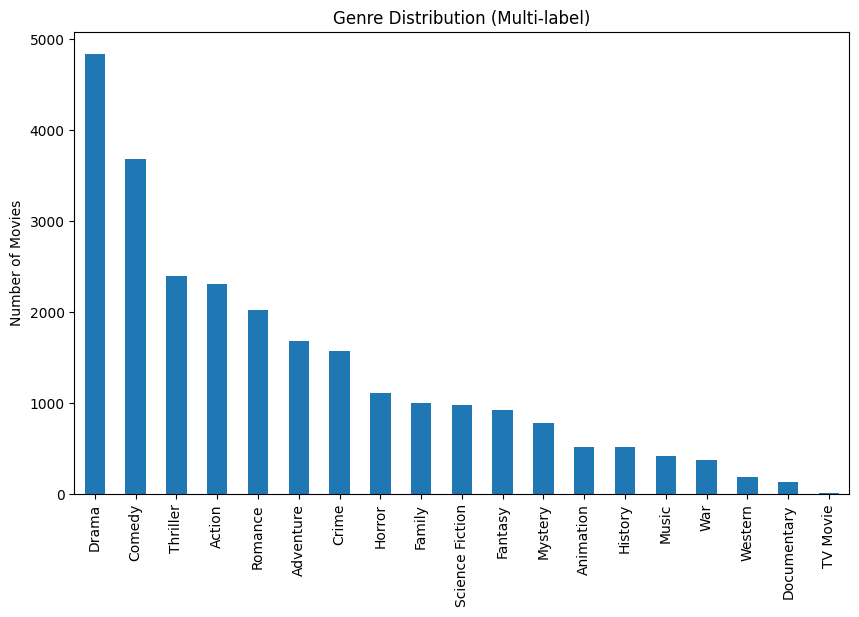

In [679]:
plt.figure(figsize=(10,6))
df[genre_cols].sum().sort_values(ascending=False).plot(kind='bar')
plt.title("Genre Distribution (Multi-label)")
plt.xticks(rotation=90)
plt.ylabel("Number of Movies")
plt.show()

👉 ⚠ **Problem**: In multi-label datasets, there's no true 'main genre' column. Picking the first True genre would bias the data.

👉 ✅ **Solution**: We'll rank genres based on their global frequency and assign the most frequent applicable genre to each movie.


In [680]:
# Create global genre ranking based on frequency
genre_order = df[genre_cols].sum().sort_values(ascending=False).index.tolist()

In [681]:
def get_ranked_main_genre(row):
    for genre in genre_order:
        if row[genre]:
            return genre
    return 'Unknown'

In [682]:
df['main_genre'] = df.apply(get_ranked_main_genre, axis=1)

In [683]:
print(df['main_genre'].value_counts())

main_genre
Drama              4832
Comedy             2479
Thriller           1233
Action              567
Horror              267
Adventure           229
Romance              82
Documentary          67
Family               64
Music                36
Western              29
Crime                19
Science Fiction      18
War                   8
History               8
Fantasy               7
Animation             5
Mystery               2
TV Movie              1
Name: count, dtype: int64


In [684]:
# Remove classes with less than 2 samples
genre_counts = df['main_genre'].value_counts()
valid_genres = genre_counts[genre_counts >= 10].index

df = df[df['main_genre'].isin(valid_genres)]

👉 Some movies contain multiple genres. To provide additional information to the classifier, we extract a secondary genre feature.


In [685]:
def get_secondary_genre(row):
    genres = [col for col in genre_cols if row[col]]
    if len(genres) >= 2:
        return genres[1]  # second genre
    return 'None'

In [686]:
df['secondary_feature'] = df.apply(get_secondary_genre, axis=1)
secondary_le = LabelEncoder()
df['secondary_feature_encoded'] = secondary_le.fit_transform(df['secondary_feature'])

In [687]:
features = ['budget', 'revenue', 'vote_average', 'vote_count', 'num_genres', 'runtime',
            'release_year', 'secondary_feature_encoded', 'belongs_to_collection',
            'num_spoken_languages']
X = df[features]
y = df['main_genre']

In [688]:
y_le = LabelEncoder()
y_encoded = y_le.fit_transform(y)

In [689]:
y

0         Comedy
1       Thriller
2         Action
3         Family
4          Drama
          ...   
9948    Thriller
9949       Drama
9950      Comedy
9951       Drama
9952      Action
Name: main_genre, Length: 9922, dtype: object

In [690]:
y_encoded

array([ 2, 11,  0, ...,  2,  5,  0])

In [691]:
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.3, random_state=42, stratify=y_encoded)

In [692]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [693]:
param_grid = {
    'max_depth': [3, 5, 7, 10, 15],
    'min_samples_split': [2, 5, 10, 20]
}

In [694]:
grid_search = GridSearchCV(DecisionTreeClassifier(random_state=42), param_grid, cv=5, scoring='f1_weighted')
grid_search.fit(X_train_scaled, y_train)

GridSearchCV(cv=5, estimator=DecisionTreeClassifier(random_state=42),
             param_grid={'max_depth': [3, 5, 7, 10, 15],
                         'min_samples_split': [2, 5, 10, 20]},
             scoring='f1_weighted')

In [695]:
print("Best Parameters:", grid_search.best_params_)

Best Parameters: {'max_depth': 7, 'min_samples_split': 2}


In [696]:
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test_scaled)

# Performance metrics
print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred, average='weighted'))
print("Classification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.6728249916022842
F1 Score: 0.6501297506617936
Classification Report:
               precision    recall  f1-score   support

           0       0.57      0.51      0.54       170
           1       0.45      0.19      0.27        69
           2       0.63      0.65      0.64       744
           3       0.00      0.00      0.00         6
           4       0.00      0.00      0.00        20
           5       0.73      0.83      0.78      1450
           6       0.00      0.00      0.00        19
           7       0.89      0.10      0.18        80
           8       0.00      0.00      0.00        11
           9       0.00      0.00      0.00        24
          10       0.00      0.00      0.00         5
          11       0.55      0.56      0.56       370
          12       0.00      0.00      0.00         9

    accuracy                           0.67      2977
   macro avg       0.29      0.22      0.23      2977
weighted avg       0.65      0.67      0.65      297

<Figure size 1000x800 with 0 Axes>

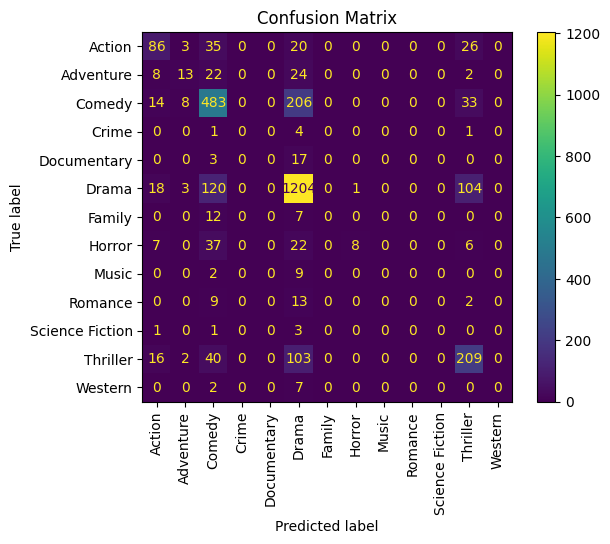

In [697]:
plt.figure(figsize=(10,8))
ConfusionMatrixDisplay.from_estimator(best_model, X_test_scaled, y_test, display_labels=y_le.classes_, xticks_rotation=90)
plt.title("Confusion Matrix")
plt.show()

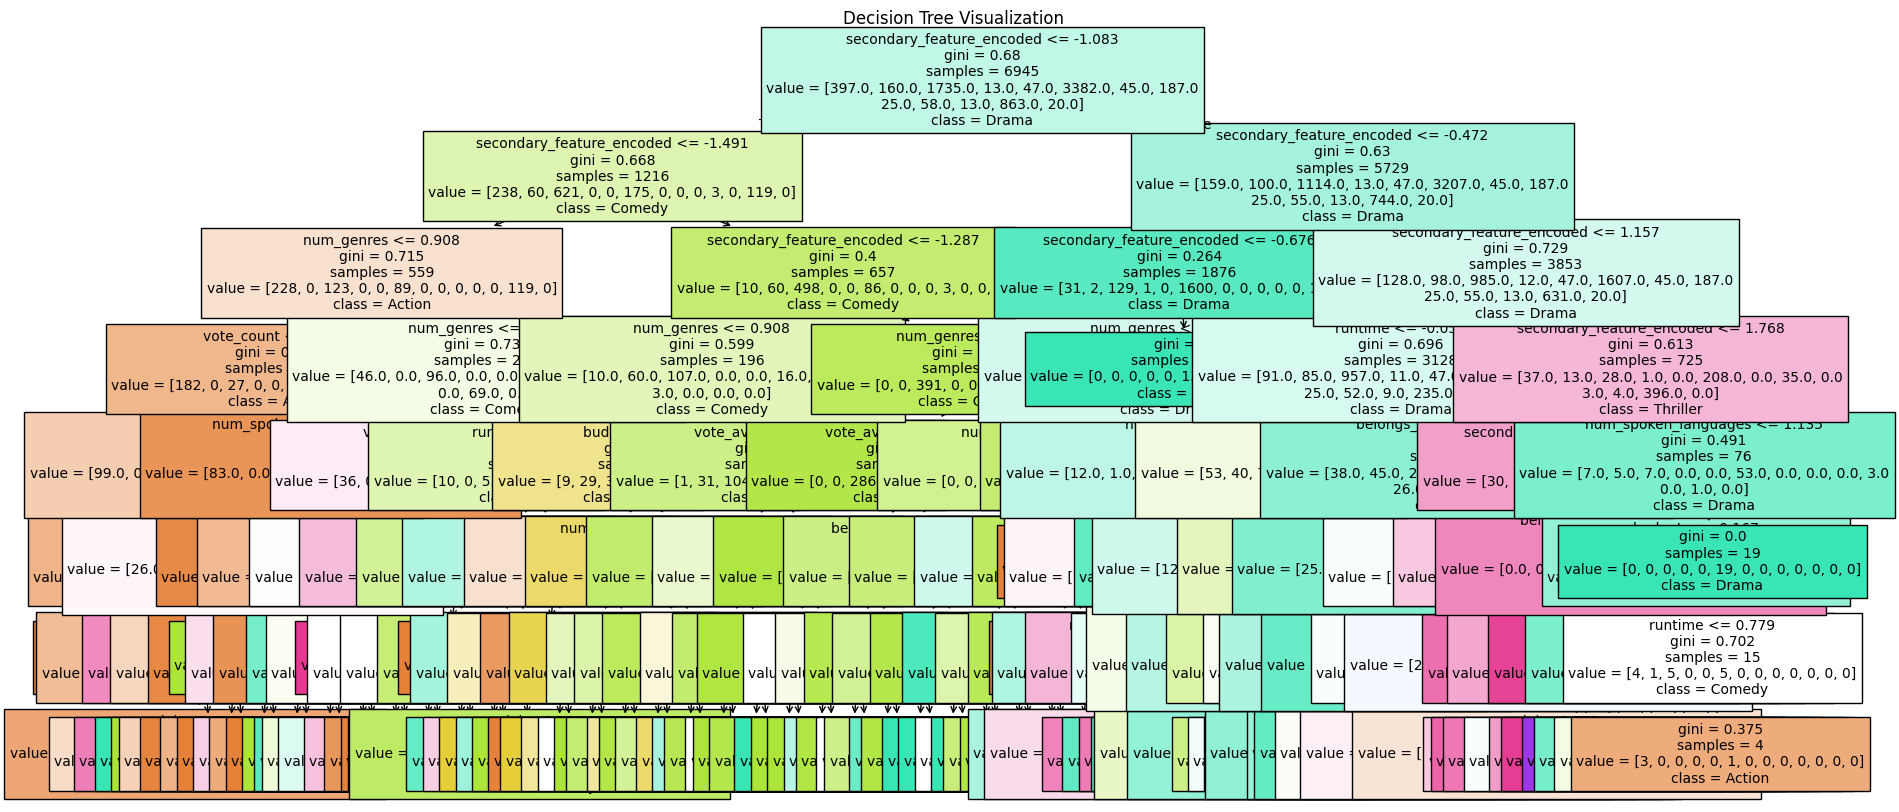

In [698]:
plt.figure(figsize=(20,10))
plot_tree(best_model, feature_names=features, class_names=le.classes_, filled=True, fontsize=10)
plt.title("Decision Tree Visualization")
plt.show()

👉 SHAP allows us to visualize global feature importance and understand how each feature contributes to predictions.

👉 Here we apply both SHAP explainability and traditional Decision Tree feature importance, so we can later compare them.

In [699]:
explainer = shap.Explainer(best_model, X_train_scaled)
shap_values = explainer(X_test_scaled, check_additivity=False)

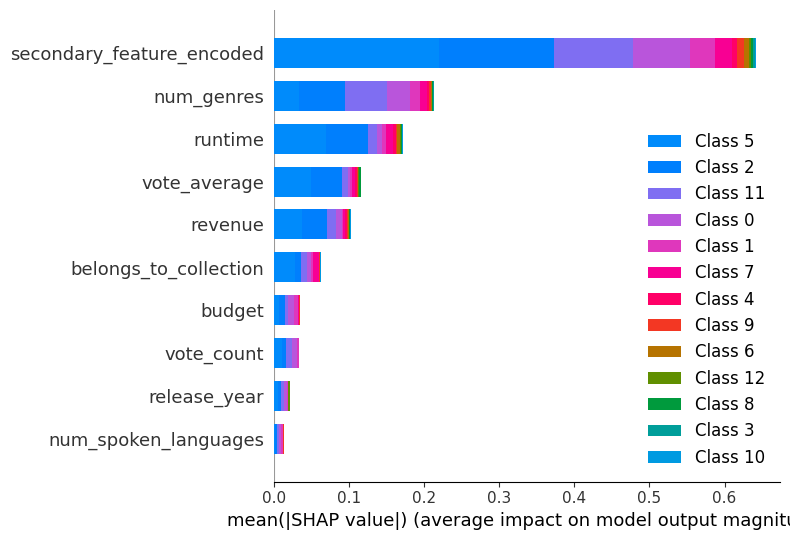

In [700]:
shap.summary_plot(shap_values, X_test, plot_type="bar")

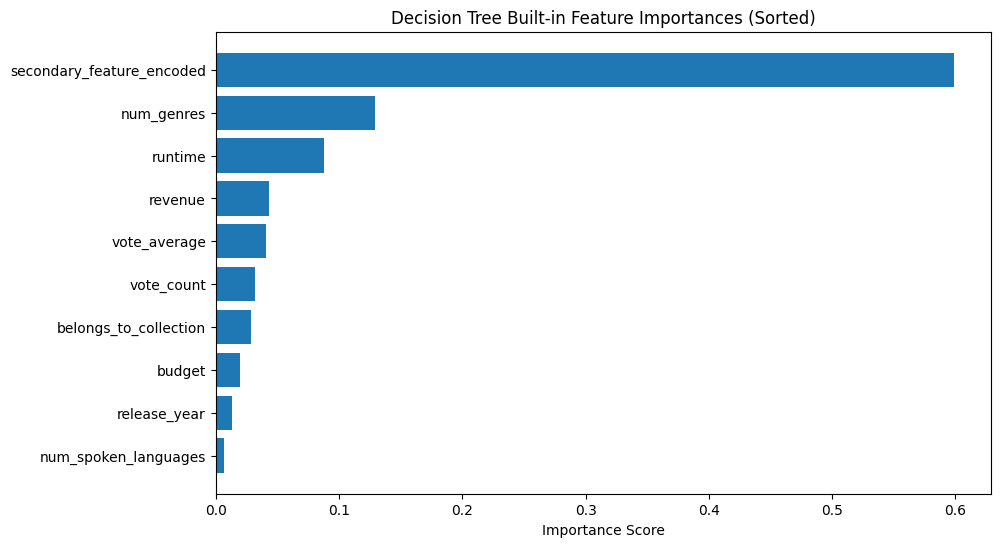

In [701]:
# Decision Tree built-in feature importance (sorted)
tree_importances = best_model.feature_importances_
sorted_idx = np.argsort(tree_importances)
plt.figure(figsize=(10,6))
plt.barh(np.array(features)[sorted_idx], tree_importances[sorted_idx])
plt.title("Decision Tree Built-in Feature Importances (Sorted)")
plt.xlabel("Importance Score")
plt.show()

## 📝 **Understanding the Difference Between SHAP and Decision Tree Feature Importance**

👉 While both SHAP and Decision Tree provide feature importance, they work very differently:

- **Decision Tree Feature Importance:**
  - Calculated from how much each feature reduces impurity (like Gini or entropy) across all splits.
  - Only provides a global view, no explanation for individual predictions.
  - Can be biased toward features with more distinct values (continuous variables).
  
- **SHAP (SHapley Additive Explanations):**
  - Based on cooperative game theory; computes how much each feature contributes to each prediction.
  - Provides both local (individual) and global (overall) feature explanations.
  - Accounts for feature interactions and shows whether features push predictions higher or lower.
  - More robust and model-agnostic.

✅ **In your project, SHAP gives you much richer interpretability**, while the Decision Tree importance can still give a simple global overview.
